In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import cellspec as spc

%matplotlib inline

In [2]:
colors = [
    '#FF1B5E',  # coral
    '#FFDB57',  # yellow
    '#438CFD',  # blue
    '#FF8C00',  # orange
    '#80F15E',  # lime green
    '#03FFFF',  # cyan
    '#5941A9',  # purple
    '#E980FC',  # magenta
    '#1A1A2E',  # navy
    '#F5F0FF',  # lavender white
    '#C17F3E',  # amber brown
]
extended_colors = [
    '#2E2A3A',
    '#FF8DAF', '#FF1B5E',
    '#FFEDA0', '#FFDB57',
    '#A4C8FE', '#438CFD',
    '#FFCF80', '#FF8C00',
    '#C4F9AE', '#80F15E',
    '#A0FFFF', '#03FFFF',
    '#A99FD4', '#5941A9',
    '#F4BFFE', '#E980FC',
    '#E8E4F0', '#C4BDD6',
    '#E8C89A', '#C17F3E'
]

In [3]:
import matplotlib.font_manager as fm
import os, glob


fm._load_fontmanager(try_read_cache=False)
# Register TeX Gyre Heros if present
for f in glob.glob(os.path.expanduser("~/.local/share/fonts/texgyreheros*.otf")):
    fm.fontManager.addfont(f)

In [4]:
mpl.rcParams.update({
    # Font
    "font.family": "sans-serif",
    "font.sans-serif": ["TeX Gyre Heros"],
    "font.size": 12,

    "axes.linewidth": 2.5,
    # Tick marks
    "xtick.major.width": 2.5,
    "ytick.major.width": 2.5,
    "xtick.minor.width": 2.0,
    "ytick.minor.width": 2.0,

    # Tick direction (outward is common in publications)
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# Load data

In [6]:
adata = ad.read_h5ad('../results/worm6_final/DNA_analysis/joint_variants_process.h5ad')

### Annotate regions

In [11]:
# gene_ov = pd.read_csv('../results/worm6_final/DNA_analysis/var_gene_overlap.csv',
#                     index_col='var_name')
# adata.var = adata.var.join(gene_ov)
adata.var

,chrom,pos,anc,der,trinuc_type,bulk_dp,bulk_vaf,is_core,module,module_dist,bulk_vaf<0.018,bulk_vaf>0.06,bulk_vaf_germline,n_cells>=2,n_carriers,in_gene,gene_id,gene_name
I-583-T>G,I,583,ATA,AGA,ATA>AGA,647.0,0.024730,False,NaN,NaN,False,False,True,True,14,False,NaN,NaN
I-584-A>C,I,584,TAC,TCC,GTA>GGA,653.0,0.052067,False,NaN,NaN,False,False,True,True,31,False,NaN,NaN
I-607-T>G,I,607,ATA,AGA,ATA>AGA,698.0,0.060172,False,NaN,NaN,False,True,False,True,38,False,NaN,NaN
I-608-A>C,I,608,TAC,TCC,GTA>GGA,695.0,0.060432,False,NaN,NaN,False,True,False,True,38,False,NaN,NaN
I-626-A>C,I,626,GAC,GCC,GTC>GGC,701.0,0.061341,False,NaN,NaN,False,True,False,True,35,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
X-17717242-G>T,X,17717242,TGA,TTA,TCA>TAA,2066.0,0.002000,False,NaN,NaN,True,False,False,False,1,True,WBGene00007068,cTel55X.1
X-17717266-C>A,X,17717266,TCA,TAA,TCA>TAA,2158.0,0.004000,False,NaN,NaN,True,False,False,False,2,True,WBGene00007068,cTel55X.1
X-17717292-G>T,X,17717292,TGT,TTT,ACA>AAA,2055.0,0.013000,False,NaN,NaN,True,False,False,True,4,True,WBGene00007068,cTel55X.1
X-17717380-C>A,X,17717380,ACT,AAT,ACT>AAT,2213.0,0.001000,False,NaN,NaN,True,False,False,False,1,True,WBGene00007068,cTel55X.1


In [ ]:
adata.var['gene_name'].star

In [ ]:
CUTICLE_PREFIXES = ('col-', 'cut-', 'idpa-')
CUTICLE_SYMBOLS = {
    # cuticle-collagen dpy genes (dpy-1, dpy-11, dpy-18+ have non-cuticle roles → excluded)
    'dpy-2', 'dpy-3', 'dpy-4', 'dpy-5', 'dpy-6', 'dpy-7',
    'dpy-8', 'dpy-9', 'dpy-10', 'dpy-13', 'dpy-14', 'dpy-17',
    # squat / roller / blister cuticle families
    'sqt-1', 'sqt-2', 'sqt-3',
    'rol-1', 'rol-3', 'rol-4', 'rol-5', 'rol-6', 'rol-8',
    'bli-1', 'bli-2', 'bli-3', 'bli-4', 'bli-5', 'bli-6',
}

### Filters

In [54]:
n_carriers = np.asarray((adata.layers['AD'] >= 1).sum(axis=0)).ravel()
adata.var['n_carriers'] = n_carriers
adata.var['bulk_vaf<0.018'] = (adata.var['bulk_vaf'] < 0.018)
adata.var['bulk_vaf>0.06'] = (adata.var['bulk_vaf']>0.06)
adata.var['bulk_vaf_germline'] = (adata.var['bulk_vaf']>0.018) & (adata.var['bulk_vaf']<0.4)

# Mutation Spectra

### All

In [43]:
spc.tl.compute_spectrum(adata, count_strategy='alt_depth', min_alt_depth=1,
                        key='all_mutations'
                       )

Computing spectrum (key='all_mutations'): 100%|██████████| 2404/2404 [00:24<00:00, 99.64cell/s] 


,ACA>AAA,ACC>AAC,ACG>AAG,ACT>AAT,CCA>CAA,CCC>CAC,CCG>CAG,CCT>CAT,GCA>GAA,GCC>GAC,...,CTG>CGG,CTT>CGT,GTA>GGA,GTC>GGC,GTG>GGG,GTT>GGT,TTA>TGA,TTC>TGC,TTG>TGG,TTT>TGT
A10_A8_F5_G1_worm6_UDI1,200,84,72,186,290,127,116,45,102,49,...,104,47,121,45,150,65,115,77,151,205
A10_A8_F6_B2_worm6_UDI1,85,38,37,81,90,61,30,39,61,19,...,52,32,74,28,75,54,52,45,92,98
A10_A9_B5_E2_worm6_UDI1,90,35,33,102,159,59,53,25,49,20,...,34,37,37,21,58,36,46,42,109,102
A10_A9_H4_C1_worm6_UDI1,189,69,47,184,304,111,98,43,77,25,...,109,36,69,26,106,45,69,35,175,175
A10_B8_B5_B1_worm6_UDI1,311,121,110,253,415,187,158,113,164,81,...,157,65,147,59,204,124,136,110,244,307
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H11_E9_D4_A3_worm6_UDI24,134,45,46,157,283,114,97,44,50,22,...,102,39,89,39,126,73,82,50,179,178
H11_E9_E4_F3_worm6_UDI24,122,45,42,129,153,70,71,43,71,31,...,58,42,42,29,80,52,80,48,102,142
H11_F7_H5_F1_worm6_UDI24,91,31,24,96,188,82,75,30,42,18,...,42,19,66,22,75,41,58,33,131,128
H12_A8_H4_H2_worm6_UDI24,93,37,33,94,140,69,61,20,49,25,...,37,25,55,22,72,28,57,32,125,106


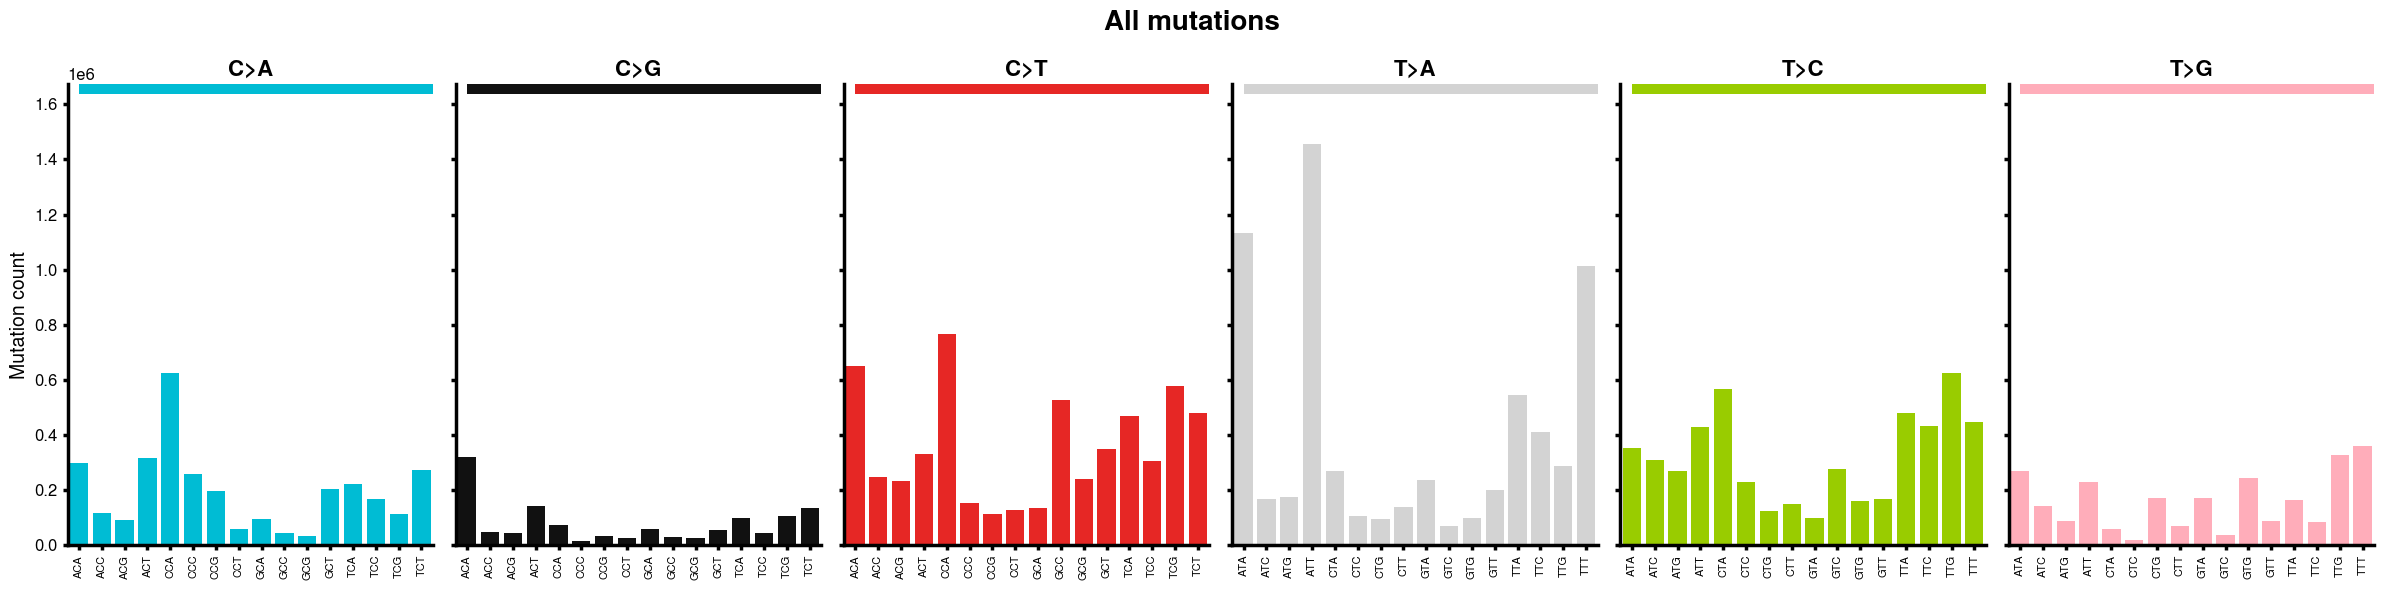

In [44]:
spc.pl.spectrum(adata, key="spectrum", title='All mutations')

### All intergenic

In [45]:
spc.tl.compute_spectrum(adata, count_strategy='alt_depth', min_alt_depth=1,
                        variant_mask=~adata.var['in_gene'].values,
                        key='intergenic'
                       )

Computing spectrum (key='intergenic'): 100%|██████████| 2404/2404 [00:17<00:00, 136.84cell/s]


,ACA>AAA,ACC>AAC,ACG>AAG,ACT>AAT,CCA>CAA,CCC>CAC,CCG>CAG,CCT>CAT,GCA>GAA,GCC>GAC,...,CTG>CGG,CTT>CGT,GTA>GGA,GTC>GGC,GTG>GGG,GTT>GGT,TTA>TGA,TTC>TGC,TTG>TGG,TTT>TGT
A10_A8_F5_G1_worm6_UDI1,131,51,27,123,228,98,80,16,32,20,...,71,29,78,22,113,26,76,38,106,151
A10_A8_F6_B2_worm6_UDI1,51,20,18,52,59,40,17,14,29,5,...,36,19,45,13,49,23,38,24,52,75
A10_A9_B5_E2_worm6_UDI1,53,16,21,71,119,51,37,6,20,6,...,21,26,35,12,48,22,33,23,88,80
A10_A9_H4_C1_worm6_UDI1,114,57,30,133,254,94,76,15,20,11,...,83,21,53,8,89,24,42,13,130,144
A10_B8_B5_B1_worm6_UDI1,166,68,55,153,322,143,102,26,61,34,...,87,32,88,23,140,59,88,57,157,208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H11_E9_D4_A3_worm6_UDI24,110,31,29,117,244,98,76,19,16,8,...,72,20,75,19,108,37,64,30,132,150
H11_E9_E4_F3_worm6_UDI24,60,22,23,74,102,47,47,14,25,9,...,39,26,22,8,64,28,64,27,76,86
H11_F7_H5_F1_worm6_UDI24,70,13,12,75,160,64,53,16,10,9,...,30,11,56,12,61,20,49,25,101,103
H12_A8_H4_H2_worm6_UDI24,67,23,22,66,120,62,45,13,21,13,...,20,20,47,9,61,17,51,20,101,87


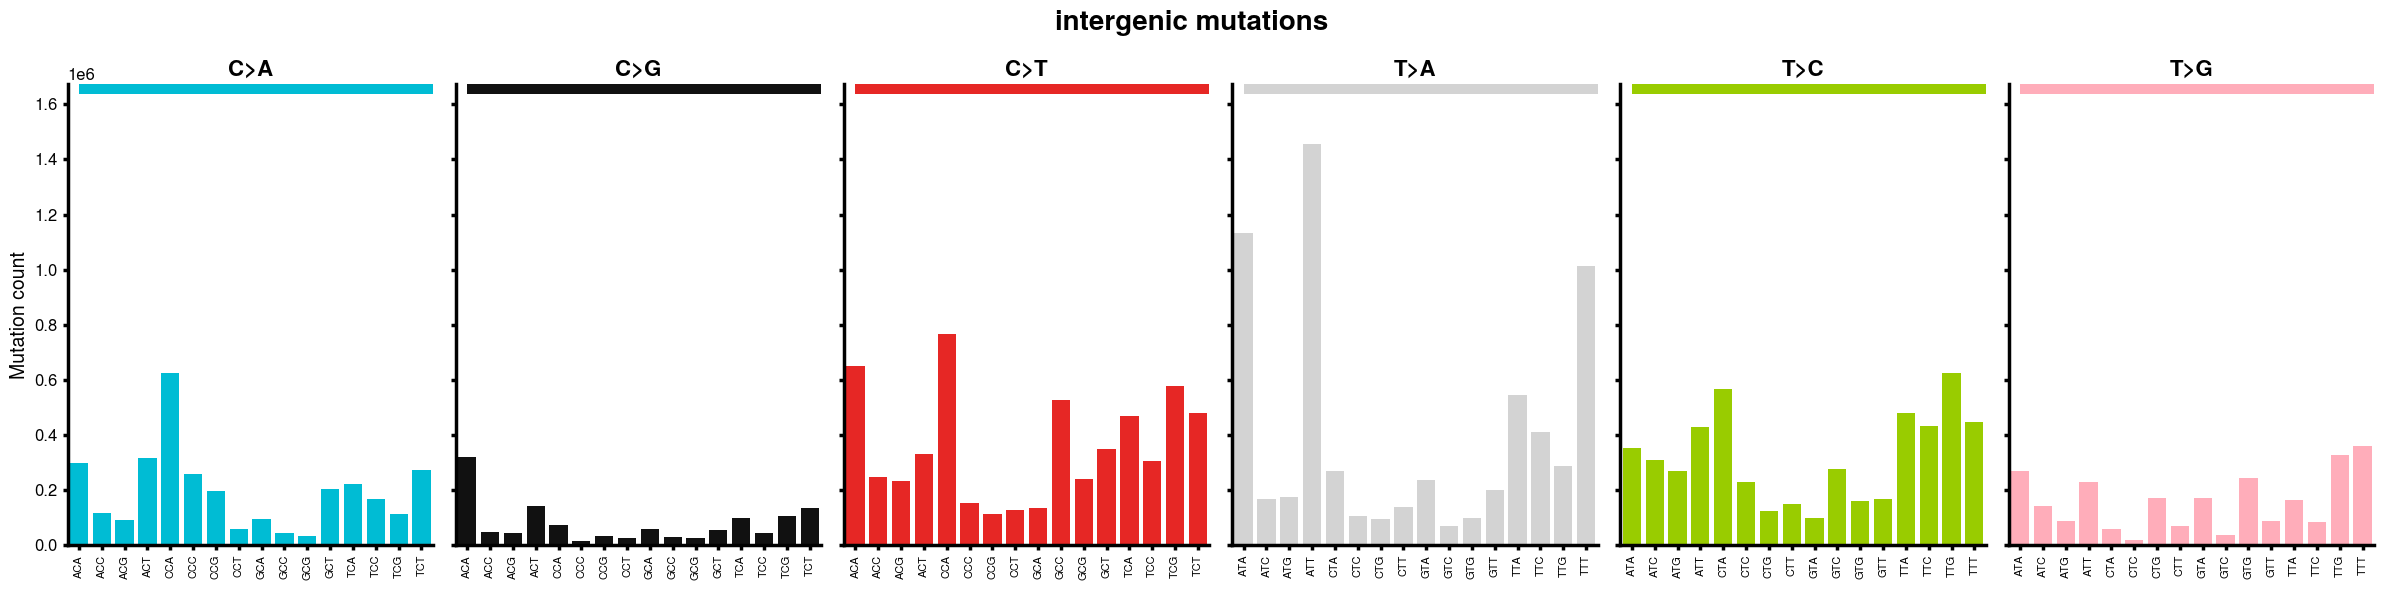

In [46]:
spc.pl.spectrum(adata, key="spectrum", title='intergenic mutations')

### All exonic

In [47]:
spc.tl.compute_spectrum(adata, count_strategy='alt_depth', min_alt_depth=1,
                        variant_mask=adata.var['in_gene'].values,
                        key='exonic'
                       )

Computing spectrum (key='exonic'): 100%|██████████| 2404/2404 [00:08<00:00, 281.00cell/s]


,ACA>AAA,ACC>AAC,ACG>AAG,ACT>AAT,CCA>CAA,CCC>CAC,CCG>CAG,CCT>CAT,GCA>GAA,GCC>GAC,...,CTG>CGG,CTT>CGT,GTA>GGA,GTC>GGC,GTG>GGG,GTT>GGT,TTA>TGA,TTC>TGC,TTG>TGG,TTT>TGT
A10_A8_F5_G1_worm6_UDI1,69,33,45,63,62,29,36,29,70,29,...,33,18,43,23,37,39,39,39,45,54
A10_A8_F6_B2_worm6_UDI1,34,18,19,29,31,21,13,25,32,14,...,16,13,29,15,26,31,14,21,40,23
A10_A9_B5_E2_worm6_UDI1,37,19,12,31,40,8,16,19,29,14,...,13,11,2,9,10,14,13,19,21,22
A10_A9_H4_C1_worm6_UDI1,75,12,17,51,50,17,22,28,57,14,...,26,15,16,18,17,21,27,22,45,31
A10_B8_B5_B1_worm6_UDI1,145,53,55,100,93,44,56,87,103,47,...,70,33,59,36,64,65,48,53,87,99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H11_E9_D4_A3_worm6_UDI24,24,14,17,40,39,16,21,25,34,14,...,30,19,14,20,18,36,18,20,47,28
H11_E9_E4_F3_worm6_UDI24,62,23,19,55,51,23,24,29,46,22,...,19,16,20,21,16,24,16,21,26,56
H11_F7_H5_F1_worm6_UDI24,21,18,12,21,28,18,22,14,32,9,...,12,8,10,10,14,21,9,8,30,25
H12_A8_H4_H2_worm6_UDI24,26,14,11,28,20,7,16,7,28,12,...,17,5,8,13,11,11,6,12,24,19


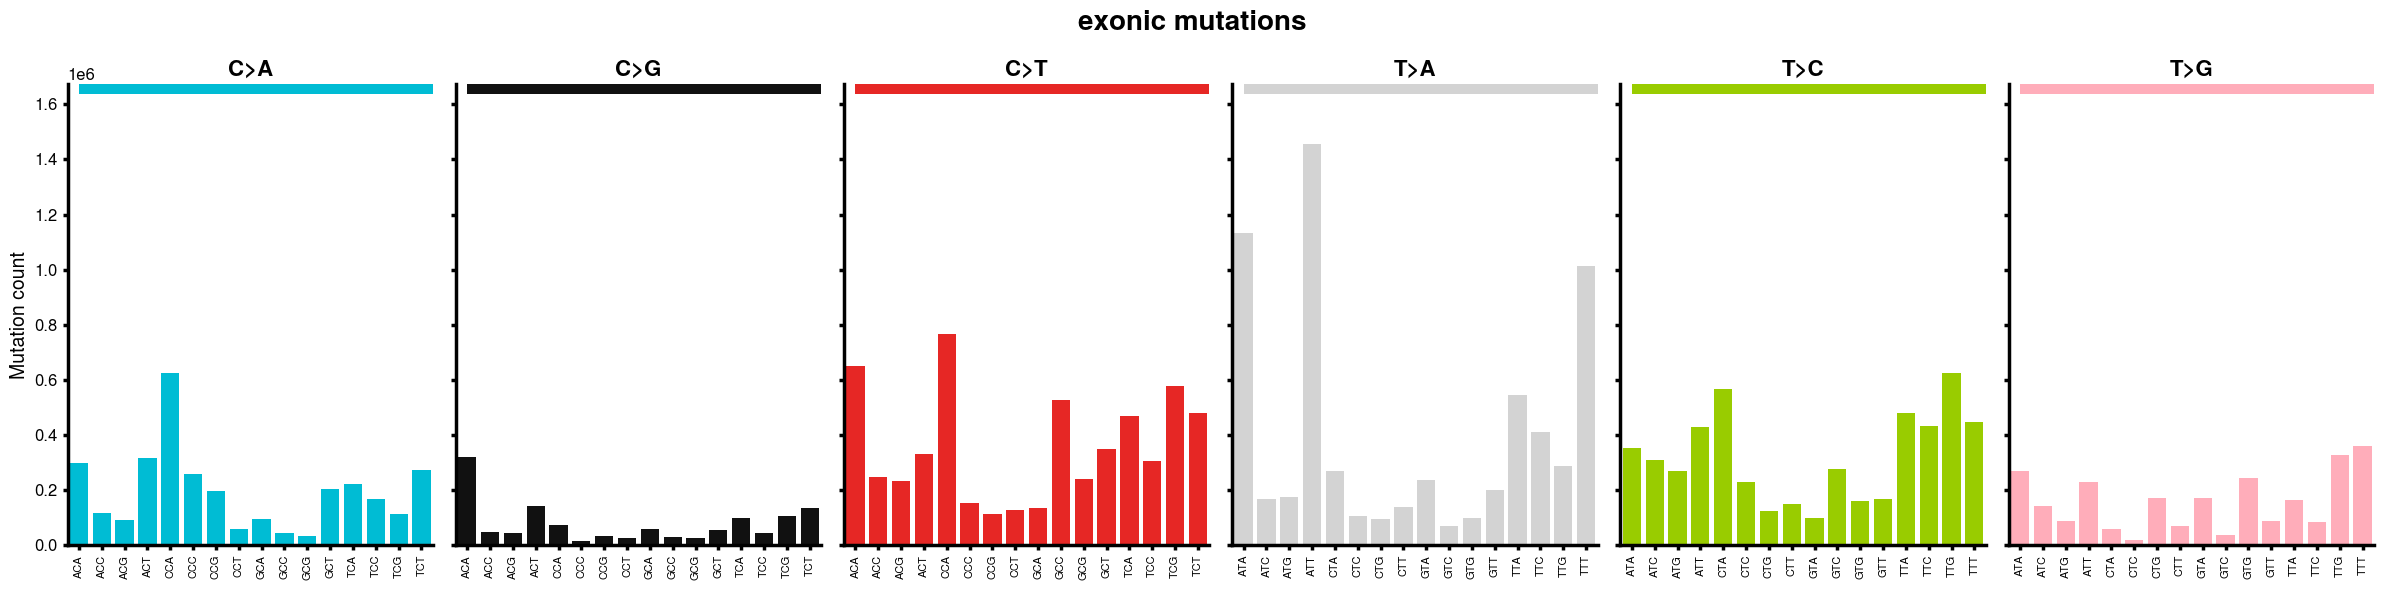

In [48]:
spc.pl.spectrum(adata, key="spectrum", title='exonic mutations')

### Singletons

In [50]:
spc.tl.compute_spectrum(adata, count_strategy='alt_depth', min_alt_depth=1,
                     variant_mask=(adata.var['n_carriers']==1).values,
                     key='singletons')

Computing spectrum (key='singletons'): 100%|██████████| 2404/2404 [00:01<00:00, 1518.04cell/s]


,ACA>AAA,ACC>AAC,ACG>AAG,ACT>AAT,CCA>CAA,CCC>CAC,CCG>CAG,CCT>CAT,GCA>GAA,GCC>GAC,...,CTG>CGG,CTT>CGT,GTA>GGA,GTC>GGC,GTG>GGG,GTT>GGT,TTA>TGA,TTC>TGC,TTG>TGG,TTT>TGT
A10_A8_F5_G1_worm6_UDI1,4,1,3,5,5,1,0,0,6,2,...,0,0,0,0,0,0,0,0,0,0
A10_A8_F6_B2_worm6_UDI1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A10_A9_B5_E2_worm6_UDI1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A10_A9_H4_C1_worm6_UDI1,16,3,4,11,2,3,3,7,7,3,...,0,0,0,0,0,0,0,0,0,1
A10_B8_B5_B1_worm6_UDI1,2,2,3,3,3,2,1,3,2,1,...,1,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H11_E9_D4_A3_worm6_UDI24,0,0,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
H11_E9_E4_F3_worm6_UDI24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
H11_F7_H5_F1_worm6_UDI24,2,0,1,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,1,0,0
H12_A8_H4_H2_worm6_UDI24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


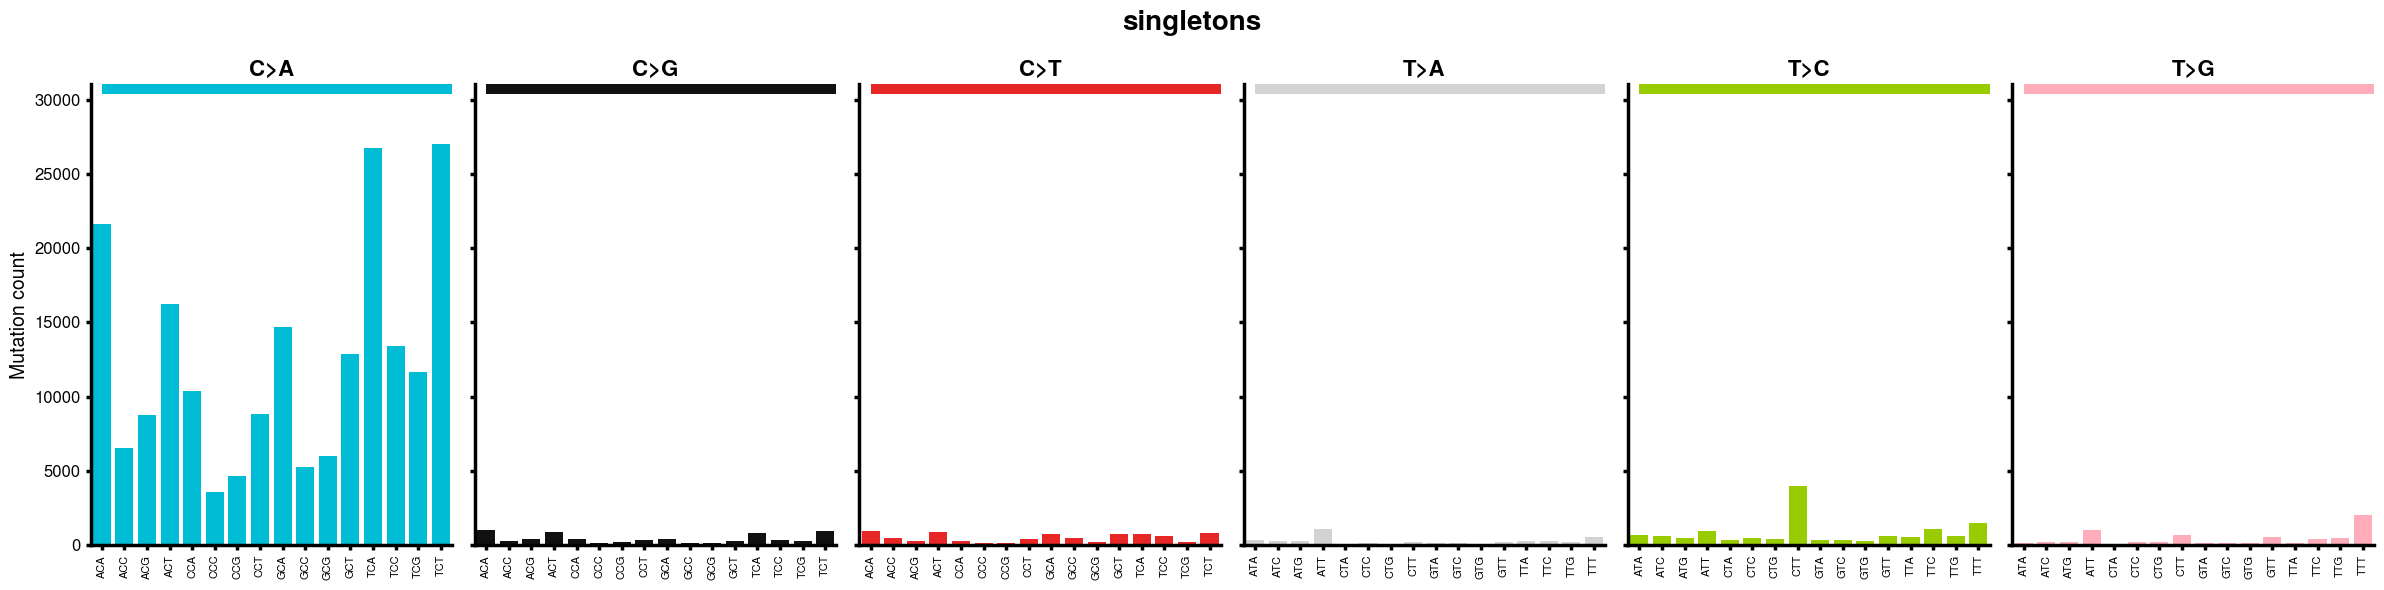

In [51]:
spc.pl.spectrum(adata, key="singletons", title='singletons')

### Core variants only

In [52]:
spc.tl.compute_spectrum(adata, count_strategy='alt_depth', min_alt_depth=1,
                     variant_mask=adata.var['is_core'].values,
                     key='core')

Computing spectrum (key='core'): 100%|██████████| 2404/2404 [00:01<00:00, 1293.36cell/s]


,ACA>AAA,ACC>AAC,ACG>AAG,ACT>AAT,CCA>CAA,CCC>CAC,CCG>CAG,CCT>CAT,GCA>GAA,GCC>GAC,...,CTG>CGG,CTT>CGT,GTA>GGA,GTC>GGC,GTG>GGG,GTT>GGT,TTA>TGA,TTC>TGC,TTG>TGG,TTT>TGT
A10_A8_F5_G1_worm6_UDI1,3,0,0,0,3,0,4,1,0,0,...,3,0,4,1,8,3,1,0,5,2
A10_A8_F6_B2_worm6_UDI1,1,1,0,3,2,2,1,1,0,1,...,3,2,11,6,4,7,0,3,7,2
A10_A9_B5_E2_worm6_UDI1,0,1,0,0,1,0,1,0,2,0,...,0,0,0,1,0,0,0,0,0,1
A10_A9_H4_C1_worm6_UDI1,0,0,0,2,4,0,1,1,1,0,...,2,1,3,4,3,3,2,2,7,3
A10_B8_B5_B1_worm6_UDI1,7,2,3,5,4,0,7,3,1,3,...,21,1,10,11,25,24,1,1,37,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H11_E9_D4_A3_worm6_UDI24,1,1,1,1,1,2,1,2,1,1,...,0,2,5,4,4,4,3,4,2,2
H11_E9_E4_F3_worm6_UDI24,2,0,0,2,0,0,0,0,0,0,...,0,2,0,1,1,3,0,2,1,2
H11_F7_H5_F1_worm6_UDI24,0,2,1,0,1,1,0,0,1,1,...,1,0,8,4,2,5,1,0,14,2
H12_A8_H4_H2_worm6_UDI24,1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,1


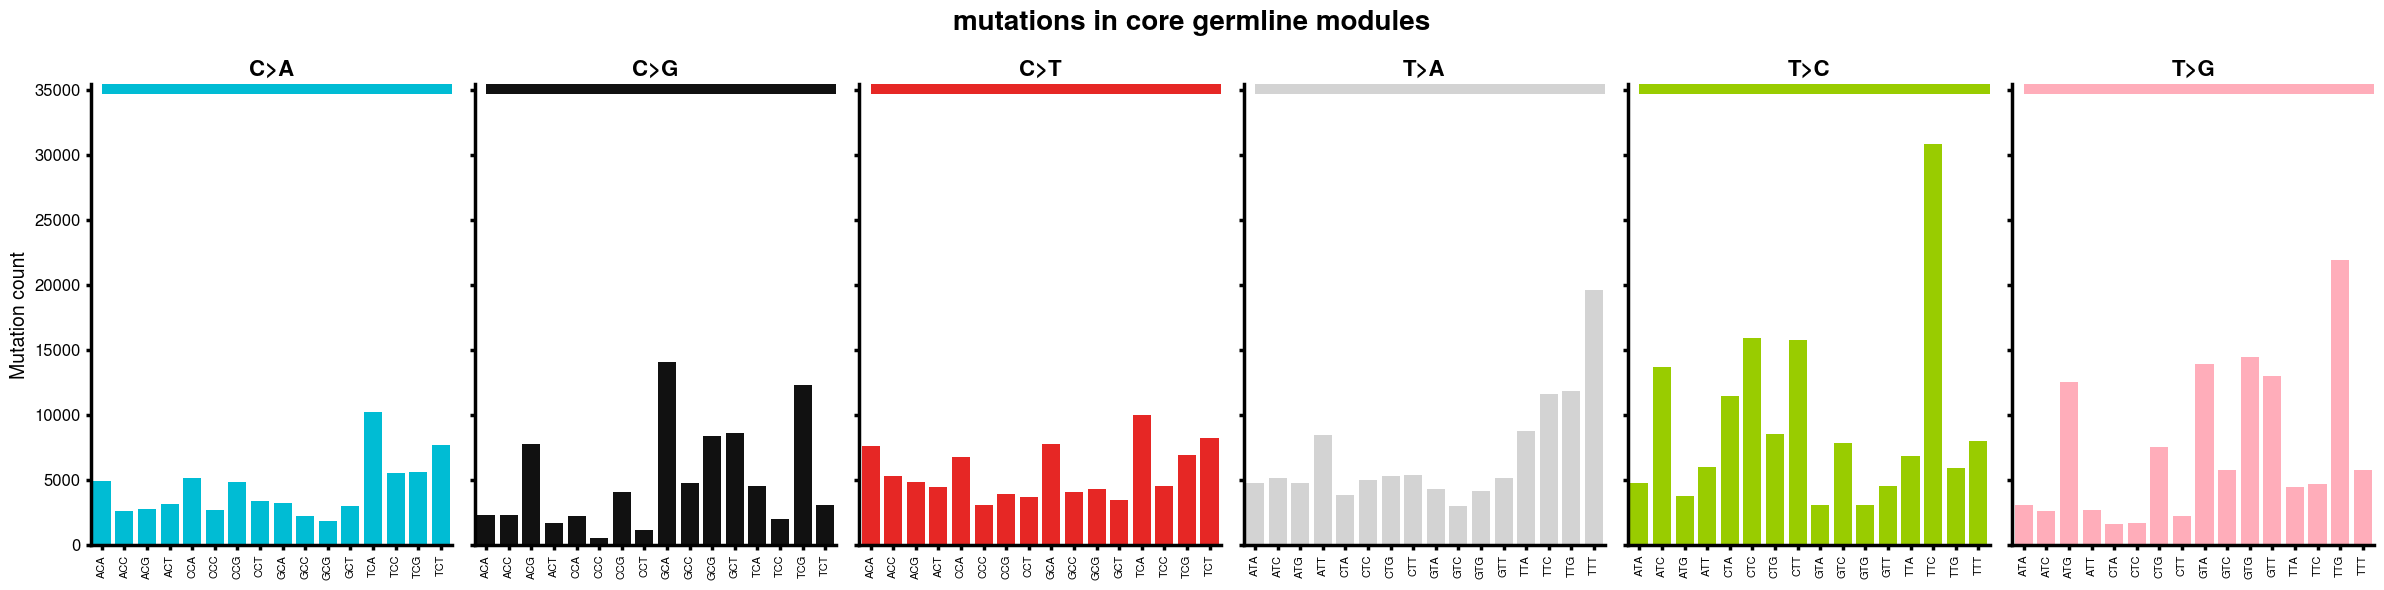

In [53]:
spc.pl.spectrum(adata, key="core", title='mutations in core germline modules')

### 0.018<VAF<0.4

In [55]:
spc.tl.compute_spectrum(adata, count_strategy='alt_depth', min_alt_depth=1,
                     variant_mask=adata.var['bulk_vaf_germline'].values,
                     key='germline')

Computing spectrum (key='germline'): 100%|██████████| 2404/2404 [00:20<00:00, 116.58cell/s]


,ACA>AAA,ACC>AAC,ACG>AAG,ACT>AAT,CCA>CAA,CCC>CAC,CCG>CAG,CCT>CAT,GCA>GAA,GCC>GAC,...,CTG>CGG,CTT>CGT,GTA>GGA,GTC>GGC,GTG>GGG,GTT>GGT,TTA>TGA,TTC>TGC,TTG>TGG,TTT>TGT
A10_A8_F5_G1_worm6_UDI1,140,71,43,137,235,98,92,13,43,36,...,100,43,109,38,141,53,106,69,121,186
A10_A8_F6_B2_worm6_UDI1,61,27,23,59,63,41,23,20,32,17,...,46,29,65,21,65,44,45,37,77,83
A10_A9_B5_E2_worm6_UDI1,60,29,15,70,127,41,45,11,25,11,...,31,33,33,18,54,28,38,37,85,94
A10_A9_H4_C1_worm6_UDI1,94,53,24,132,256,91,79,16,28,19,...,103,34,62,22,99,37,62,30,144,156
A10_B8_B5_B1_worm6_UDI1,199,101,69,181,331,146,124,55,80,65,...,148,55,127,51,187,106,125,105,209,268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H11_E9_D4_A3_worm6_UDI24,107,36,34,133,248,100,80,22,19,17,...,98,34,80,30,118,59,70,43,152,155
H11_E9_E4_F3_worm6_UDI24,78,35,25,84,106,52,57,15,26,23,...,52,36,37,24,68,38,71,39,77,115
H11_F7_H5_F1_worm6_UDI24,64,24,12,73,159,60,59,14,15,9,...,41,16,61,18,70,36,51,27,107,113
H12_A8_H4_H2_worm6_UDI24,66,28,23,69,115,52,47,9,23,19,...,35,20,47,16,69,21,50,28,104,90


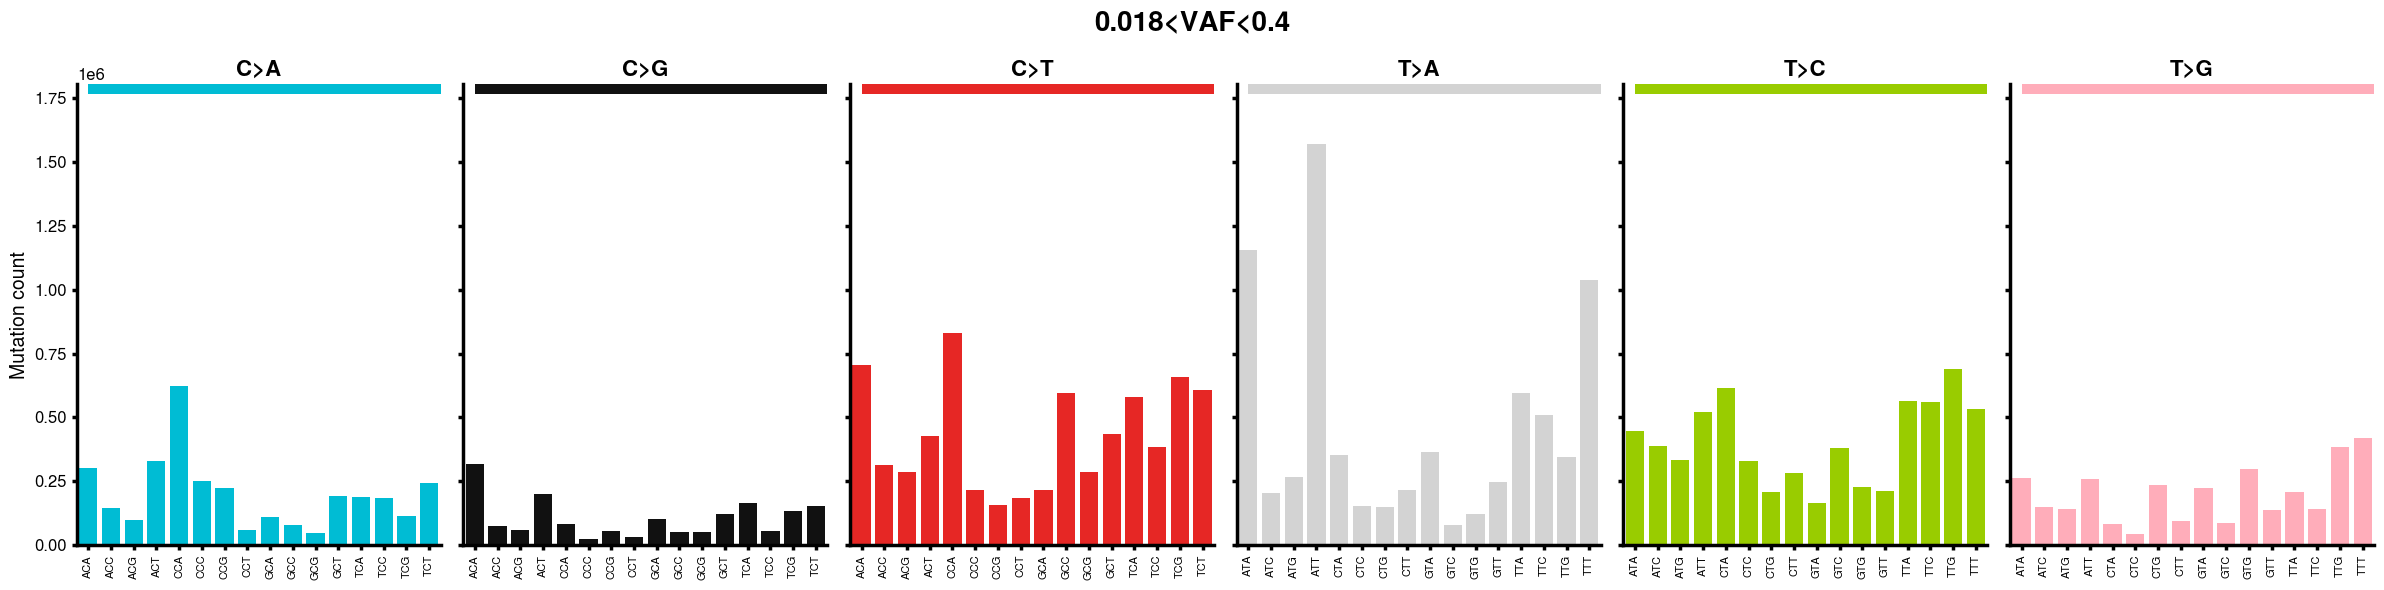

In [56]:
spc.pl.spectrum(adata, key="germline", title='0.018<VAF<0.4')

### vaf<0.018

In [287]:
spc.tl.compute_spectrum(adata, count_strategy='alt_depth', min_alt_depth=1,
                     variant_mask=adata.var['bulk_vaf<0.018'].values,
                     key='bulk_vaf<0.018')

Computing spectrum (key='bulk_vaf<0.018'): 100%|██████████| 2404/2404 [00:03<00:00, 739.68cell/s]


,ACA>AAA,ACC>AAC,ACG>AAG,ACT>AAT,CCA>CAA,CCC>CAC,CCG>CAG,CCT>CAT,GCA>GAA,GCC>GAC,...,CTG>CGG,CTT>CGT,GTA>GGA,GTC>GGC,GTG>GGG,GTT>GGT,TTA>TGA,TTC>TGC,TTG>TGG,TTT>TGT
A10_A8_F5_G1_worm6_UDI1,41,10,20,33,32,12,13,28,48,11,...,2,1,4,3,0,3,3,3,5,3
A10_A8_F6_B2_worm6_UDI1,12,4,6,6,13,7,4,12,20,1,...,1,1,4,2,3,4,1,1,2,1
A10_A9_B5_E2_worm6_UDI1,20,3,9,20,17,6,4,9,17,8,...,1,1,0,2,2,1,2,1,2,1
A10_A9_H4_C1_worm6_UDI1,84,13,18,40,36,11,16,27,42,6,...,3,1,0,1,4,2,2,0,1,6
A10_B8_B5_B1_worm6_UDI1,92,15,30,53,59,24,23,47,72,13,...,4,5,6,4,9,6,3,1,1,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H11_E9_D4_A3_worm6_UDI24,11,3,5,7,15,5,7,17,17,5,...,0,1,0,4,1,1,3,1,3,6
H11_E9_E4_F3_worm6_UDI24,25,3,7,22,29,8,8,17,34,6,...,0,0,0,3,3,1,0,1,5,4
H11_F7_H5_F1_worm6_UDI24,20,4,7,11,15,7,7,10,23,7,...,0,0,1,2,2,3,0,2,0,4
H12_A8_H4_H2_worm6_UDI24,18,1,4,11,10,3,7,9,18,4,...,1,0,2,2,1,1,0,0,1,1


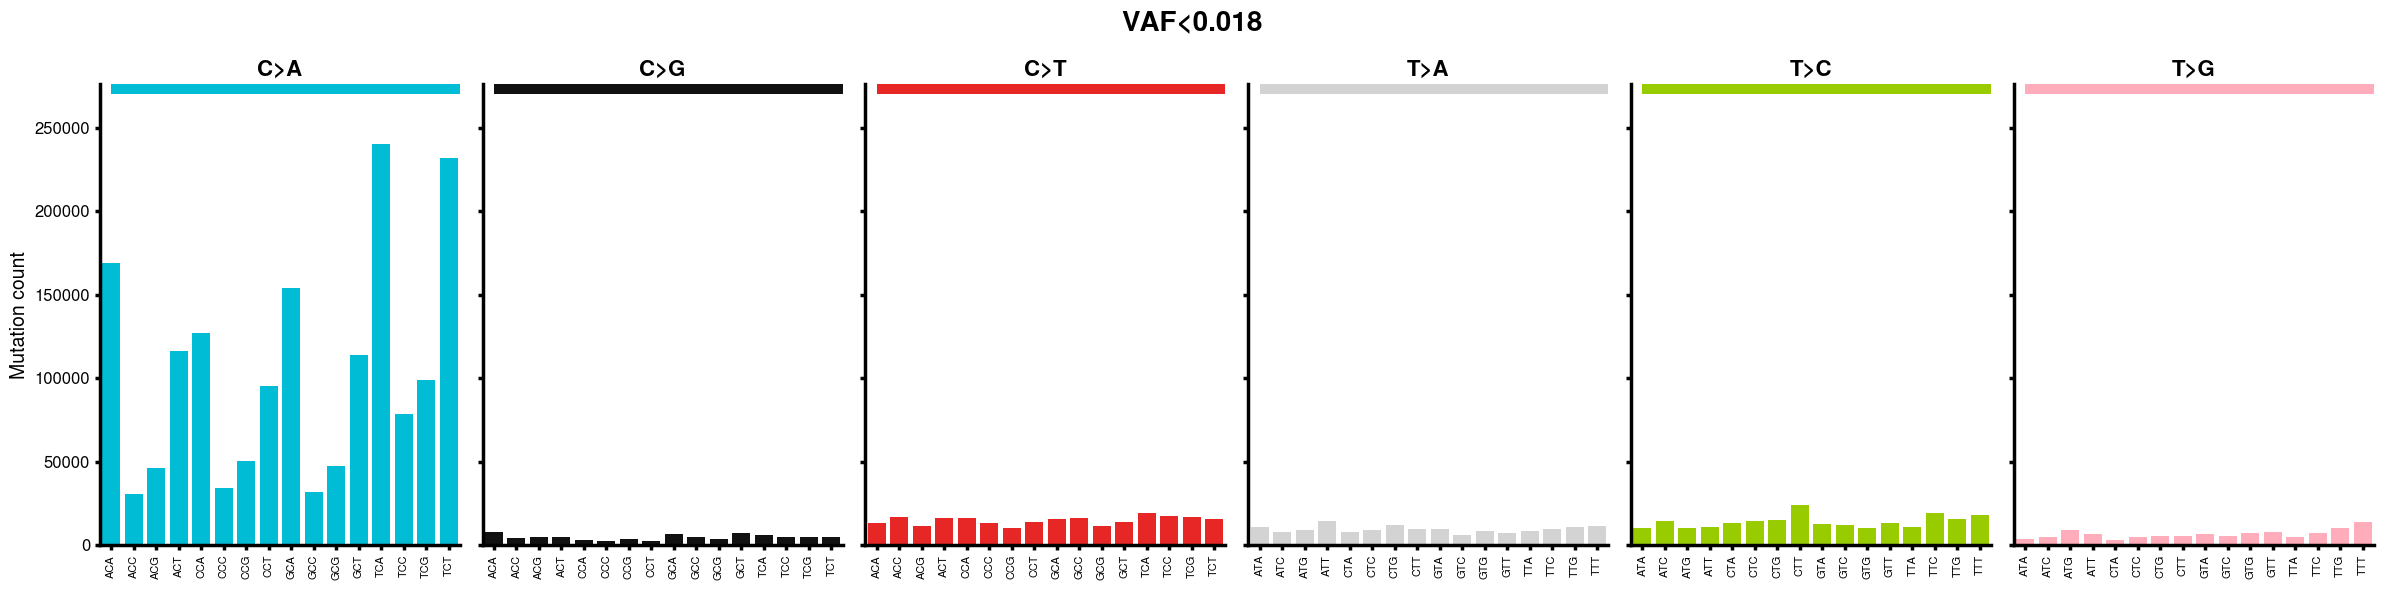

In [288]:
spc.pl.spectrum(adata, key="bulk_vaf<0.018", title='VAF<0.018')

### vaf<0.018 + Exonic

In [18]:
adata.var['genic_low_vaf'] = (adata.var['in_gene']) & (adata.var['bulk_vaf<0.018'])

In [20]:
spc.tl.compute_spectrum(adata, count_strategy='alt_depth', min_alt_depth=1,
                     variant_mask=adata.var['genic_low_vaf'].values,
                     key='genic_low_vaf')

Computing spectrum (key='genic_low_vaf'): 100%|██████████| 2404/2404 [00:03<00:00, 716.13cell/s]


,ACA>AAA,ACC>AAC,ACG>AAG,ACT>AAT,CCA>CAA,CCC>CAC,CCG>CAG,CCT>CAT,GCA>GAA,GCC>GAC,...,CTG>CGG,CTT>CGT,GTA>GGA,GTC>GGC,GTG>GGG,GTT>GGT,TTA>TGA,TTC>TGC,TTG>TGG,TTT>TGT
A10_A8_F5_G1_worm6_UDI1,28,6,16,22,24,10,9,19,35,6,...,1,0,1,3,0,2,1,2,3,3
A10_A8_F6_B2_worm6_UDI1,11,4,4,6,11,5,3,10,17,1,...,1,1,4,2,2,2,0,1,2,0
A10_A9_B5_E2_worm6_UDI1,15,3,6,14,15,5,2,8,12,6,...,0,1,0,2,2,1,1,1,2,0
A10_A9_H4_C1_worm6_UDI1,54,4,12,29,26,9,10,19,30,4,...,2,1,0,1,3,1,1,0,0,4
A10_B8_B5_B1_worm6_UDI1,63,11,19,41,45,18,14,42,47,7,...,4,4,2,4,7,3,3,1,1,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H11_E9_D4_A3_worm6_UDI24,4,3,4,5,13,2,3,12,14,3,...,0,1,0,3,1,1,1,0,2,3
H11_E9_E4_F3_worm6_UDI24,22,3,5,16,24,8,6,13,24,4,...,0,0,0,3,2,1,0,1,3,1
H11_F7_H5_F1_worm6_UDI24,14,3,4,8,10,5,7,7,22,6,...,0,0,0,0,2,2,0,1,0,3
H12_A8_H4_H2_worm6_UDI24,11,1,3,11,7,2,5,4,8,2,...,1,0,2,2,0,1,0,0,1,1


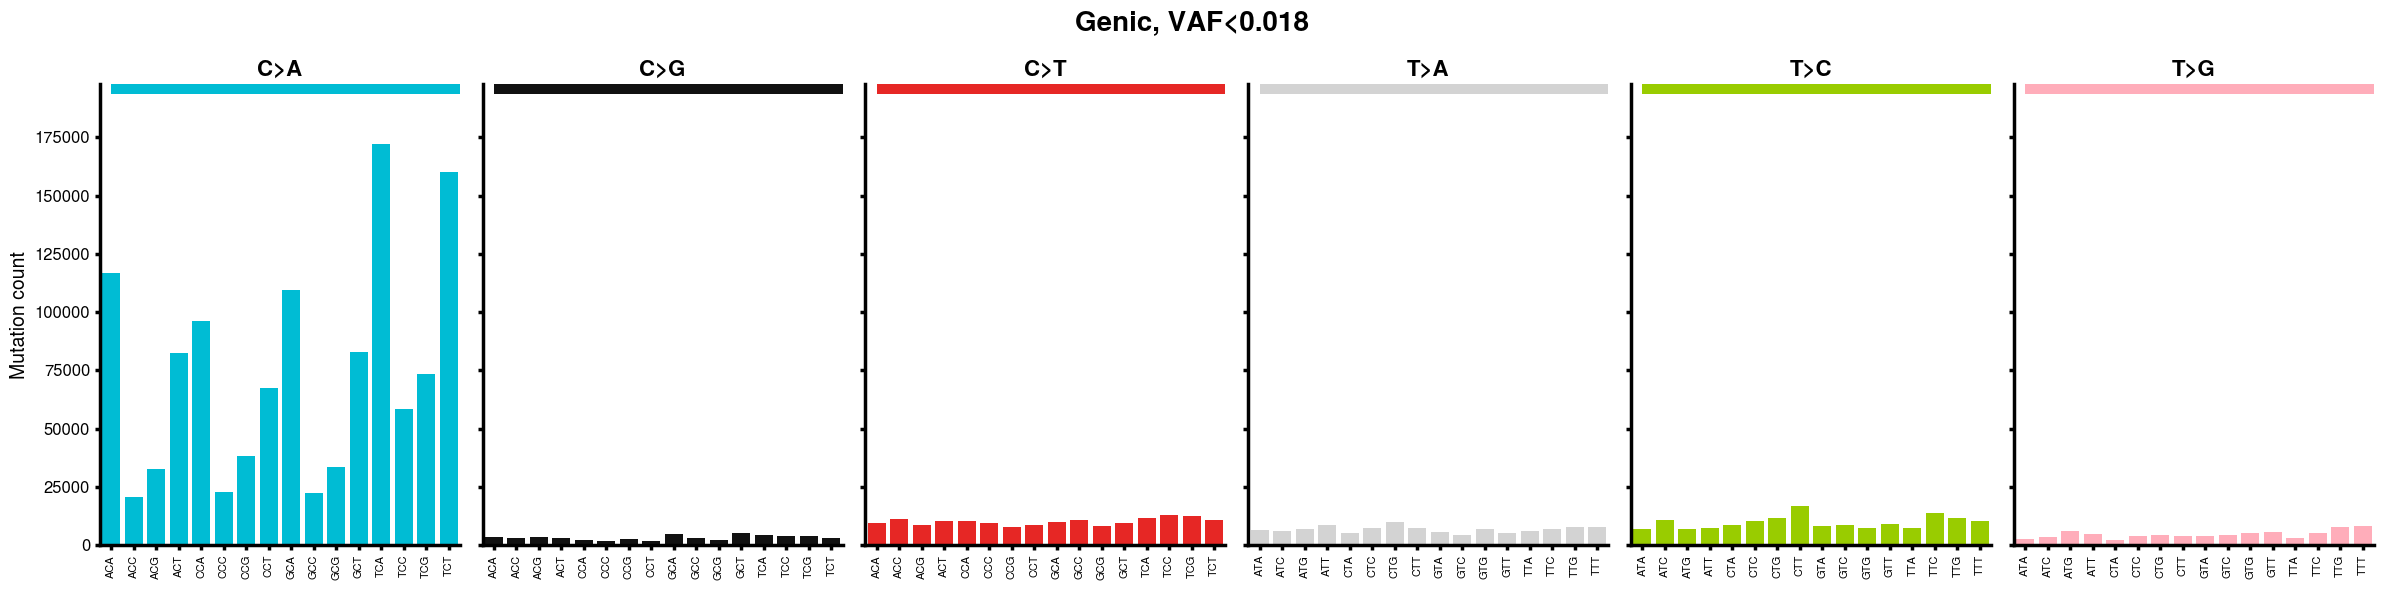

In [21]:
spc.pl.spectrum(adata, key="genic_low_vaf", title='Genic, VAF<0.018')

### vaf<0.018 + Intergenic

In [30]:
adata.var['intergenic_low_vaf'] = (~adata.var['in_gene']) & (adata.var['bulk_vaf<0.018'])

In [31]:
spc.tl.compute_spectrum(adata, count_strategy='alt_depth', min_alt_depth=1,
                     variant_mask=adata.var['intergenic_low_vaf'].values,
                     key='intergenic_low_vaf')

Computing spectrum (key='intergenic_low_vaf'): 100%|██████████| 2404/2404 [00:01<00:00, 1226.94cell/s]


,ACA>AAA,ACC>AAC,ACG>AAG,ACT>AAT,CCA>CAA,CCC>CAC,CCG>CAG,CCT>CAT,GCA>GAA,GCC>GAC,...,CTG>CGG,CTT>CGT,GTA>GGA,GTC>GGC,GTG>GGG,GTT>GGT,TTA>TGA,TTC>TGC,TTG>TGG,TTT>TGT
A10_A8_F5_G1_worm6_UDI1,13,4,4,11,8,2,4,9,13,5,...,1,1,3,0,0,1,2,1,2,0
A10_A8_F6_B2_worm6_UDI1,1,0,2,0,2,2,1,2,3,0,...,0,0,0,0,1,2,1,0,0,1
A10_A9_B5_E2_worm6_UDI1,5,0,3,6,2,1,2,1,5,2,...,1,0,0,0,0,0,1,0,0,1
A10_A9_H4_C1_worm6_UDI1,30,9,6,11,10,2,6,8,12,2,...,1,0,0,0,1,1,1,0,1,2
A10_B8_B5_B1_worm6_UDI1,29,4,11,12,14,6,9,5,25,6,...,0,1,4,0,2,3,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H11_E9_D4_A3_worm6_UDI24,7,0,1,2,2,3,4,5,3,2,...,0,0,0,1,0,0,2,1,1,3
H11_E9_E4_F3_worm6_UDI24,3,0,2,6,5,0,2,4,10,2,...,0,0,0,0,1,0,0,0,2,3
H11_F7_H5_F1_worm6_UDI24,6,1,3,3,5,2,0,3,1,1,...,0,0,1,2,0,1,0,1,0,1
H12_A8_H4_H2_worm6_UDI24,7,0,1,0,3,1,2,5,10,2,...,0,0,0,0,1,0,0,0,0,0


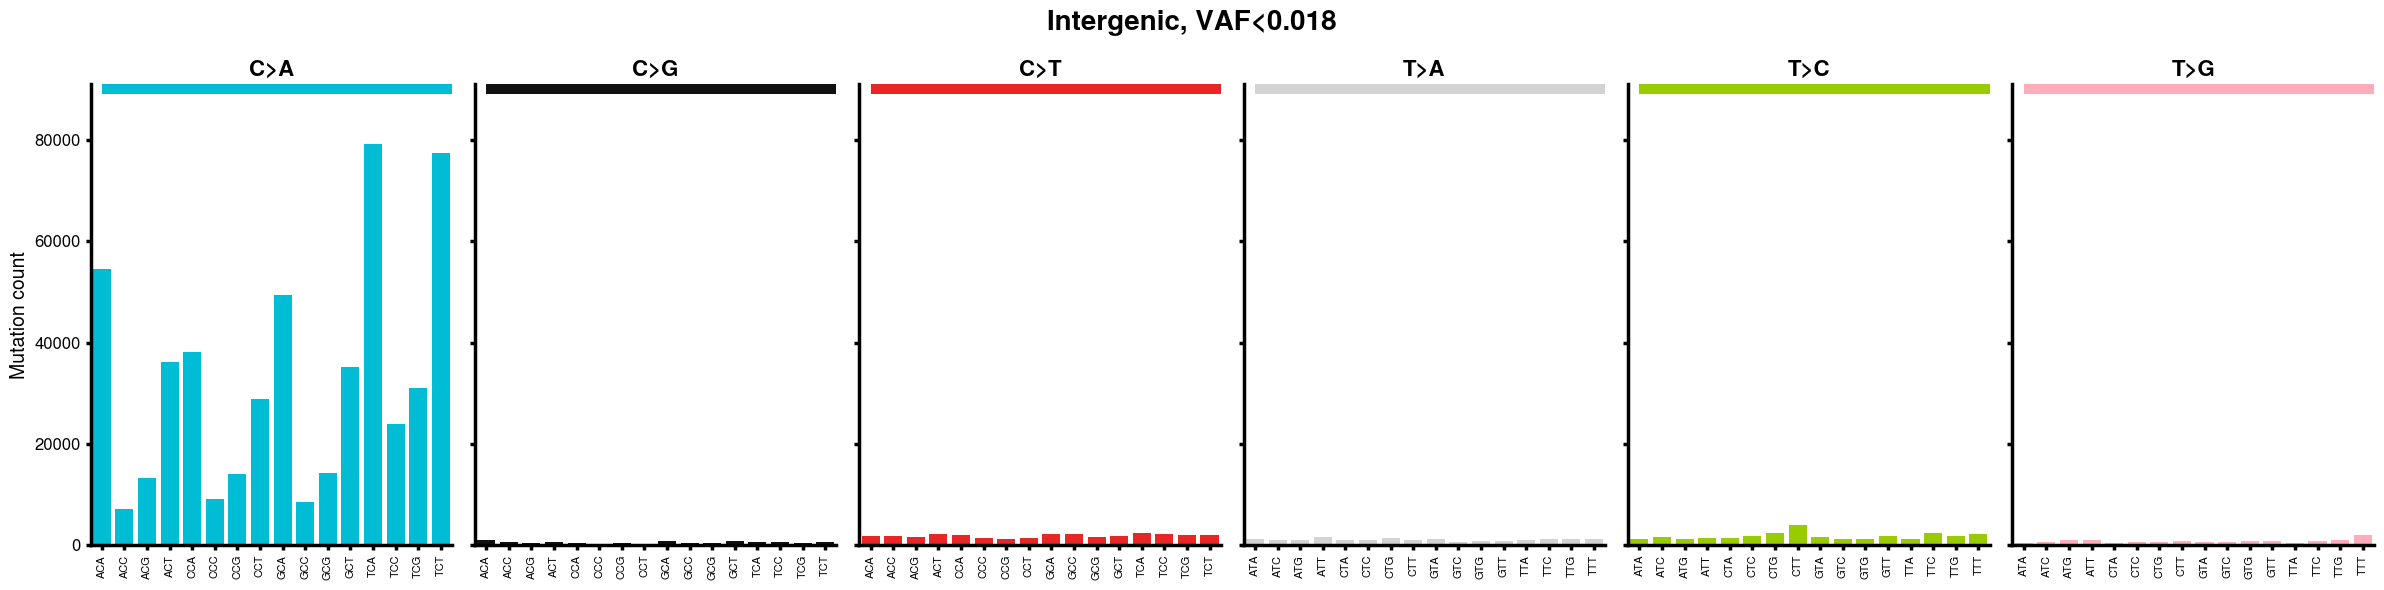

In [32]:
spc.pl.spectrum(adata, key="bulk_vaf<0.018", title='Intergenic, VAF<0.018')

# Pseudo-bulked individual worms